# 2. Як насправді працює інференс LLM

**Розділ довідника:** [`sections/02-inferens.md`](../sections/02-inferens.md)

**Потрібно: нічого** — жодних ключів, жодного GPU, жодної мережі. Усі числа
обчислюються з реальних `config.json` і прайс-листів, збережених у `research/`.
Остання клітинка з реальним запитом — опційна і потребує `ANTHROPIC_API_KEY`.

**Що ви зробите:**

1. **Порахуєте пам'ять під KV-кеш** для чотирьох реальних моделей — на токен, на
   контекст, на батч і на тип даних. Формула з документації NVIDIA.
2. Перевірите формулу **проти опублікованої таблиці HF** і знайдете в ній помилку
   в рядку 405B.
3. Побачите, як **GQA зменшує кеш у 4–8 разів**, а sliding window — удвічі.
4. Змоделюєте **профіль затримки**: TTFT + TPOT × токени, і дізнаєтеся, коли
   оптимізувати TTFT марно.
5. Порахуєте, **чому ціна виходу вища за ціну входу**, на реальних цінах.
6. Побачите, як **накопичення контексту** робить діалог дорожчим за квадратичним
   законом, і що з цим робить compaction.
7. Знайдете **поріг, за якого префіксний кеш окупається**.

> Головна думка: префіл паралельний і compute-bound, декодування послідовне й
> memory-bound. Звідси випливає все інше — ціни, затримка, ліміти й розмір пам'яті.

## Налаштування

In [1]:
# Спільне налаштування для всіх ноутбуків довідника.
# Шукає корінь репозиторію, щоб шляхи на кшталт research/... працювали
# незалежно від того, звідки запущено Jupyter.
import pathlib
import sys

_cwd = pathlib.Path.cwd()
if (_cwd / "research").is_dir():
    ROOT = _cwd
elif (_cwd.parent / "research").is_dir():
    ROOT = _cwd.parent
else:
    raise RuntimeError(
        f"Не знайдено каталог research/ ні в {_cwd}, ні в {_cwd.parent}. "
        "Запускайте Jupyter з кореня репозиторію або з теки notebooks/."
    )

print("Python :", sys.version.split()[0])
print("Корінь :", ROOT)

Python : 3.12.3
Корінь : /home/volodymyr/PycharmProjects/ai-engineer-docs


In [2]:
# Версії бібліотек, використаних у цьому ноутбуку (для відтворюваності).
import importlib

for _name in ("nbformat", "jinja2", "transformers", "anthropic"):
    try:
        _mod = importlib.import_module(_name)
        print(f"{_name:14} {getattr(_mod, '__version__', '?')}")
    except ImportError:
        print(f"{_name:14} НЕ ВСТАНОВЛЕНО (для цього ноутбука не обов'язково)")

nbformat       5.9.1
jinja2         3.1.2
transformers   НЕ ВСТАНОВЛЕНО (для цього ноутбука не обов'язково)
anthropic      НЕ ВСТАНОВЛЕНО (для цього ноутбука не обов'язково)


## 2.1 Токен як одиниця білінгу

У рахунку токени не однорідні: `input_tokens`, `cache_creation_input_tokens`,
`cache_read_input_tokens` і `output_tokens` — чотири категорії з різними цінами.
Поле `input_tokens` при цьому **не** означає «всі вхідні токени»: документація
Claude API визначає

```text
total_input_tokens = cache_read_input_tokens + cache_creation_input_tokens + input_tokens
```

Порахуємо реальний запит: 200 000 токенів документа читаються з кешу, питання — 50
токенів, відповідь — 812 токенів. Ціни — з `research/02/pricing.md`.

In [3]:
# Ціни за мільйон токенів (Anthropic, 09.2026): research/02/pricing.md
PRICES = {
    # model: (input, output, cache_write_5m, cache_write_1h, cache_read)
    "claude-sonnet-5": (2.0, 10.0, 2.50, 4.0, 0.20),
    "claude-opus-5": (5.0, 25.0, 6.25, 10.0, 0.50),
    "claude-haiku-4-5": (1.0, 5.0, 1.25, 2.0, 0.10),
}

# Реальний розклад usage: документ із кешу + коротке питання + відповідь.
USAGE = {
    "input_tokens": 50,
    "cache_creation_input_tokens": 0,
    "cache_read_input_tokens": 200_000,
    "output_tokens": 812,
}


def total_input_tokens(usage: dict) -> int:
    """Повний вхід запиту, а не лише поле input_tokens."""
    return (usage["input_tokens"]
            + usage["cache_creation_input_tokens"]
            + usage["cache_read_input_tokens"])


def cost_usd(model_id: str, usage: dict) -> float:
    """Ціна запиту за розкладом usage. 5-хвилинний запис у кеш."""
    inp, out, cw5, _cw1h, read = PRICES[model_id]
    return (usage["input_tokens"] / 1e6 * inp
            + usage["cache_creation_input_tokens"] / 1e6 * cw5
            + usage["cache_read_input_tokens"] / 1e6 * read
            + usage["output_tokens"] / 1e6 * out)


full_input = total_input_tokens(USAGE)
print(f"запит обробив вхідних токенів : {full_input:,}")
print(f"з них у полі input_tokens     : {USAGE['input_tokens']:,}"
      f" ({USAGE['input_tokens'] / full_input * 100:.2f}%)")
print()
print(f"{'модель':18}{'з кешем':>12}{'без кешу':>12}{'економія':>11}")
for model_id in PRICES:
    cached = cost_usd(model_id, USAGE)
    plain_usage = dict(USAGE, input_tokens=full_input, cache_read_input_tokens=0)
    plain = cost_usd(model_id, plain_usage)
    print(f"{model_id:18}{cached:>11.5f}$ {plain:>11.5f}$ {(1 - cached / plain) * 100:>9.1f}%")

запит обробив вхідних токенів : 200,050
з них у полі input_tokens     : 50 (0.02%)

модель                 з кешем    без кешу   економія
claude-sonnet-5       0.04822$     0.40822$      88.2%
claude-opus-5         0.12055$     1.02055$      88.2%
claude-haiku-4-5      0.02411$     0.20411$      88.2%


Кеш-читання коштує 10% базової ціни входу, тому 200 050 вхідних токенів
перетворюються на кілька десятих цента. Розкладемо один запит на статті, щоб
побачити, що важить найбільше.

In [4]:
breakdown_model = "claude-sonnet-5"
total = cost_usd(breakdown_model, USAGE)
read_price = PRICES[breakdown_model][4]

rows = [
    ("input_tokens", USAGE["input_tokens"], PRICES[breakdown_model][0]),
    ("cache_creation_input_tokens", USAGE["cache_creation_input_tokens"], PRICES[breakdown_model][2]),
    ("cache_read_input_tokens", USAGE["cache_read_input_tokens"], read_price),
    ("output_tokens", USAGE["output_tokens"], PRICES[breakdown_model][1]),
]
print(f"{'категорія':>28}{'токенів':>12}{'$/MTok':>9}{'ціна':>12}{'частка':>9}")
for category, token_count, unit_price in rows:
    part = token_count / 1e6 * unit_price
    print(f"{category:>28}{token_count:>12,}{unit_price:>9.2f}{part:>11.5f}$ {part / total * 100:>7.1f}%")
print(f"{'РАЗОМ':>28}{full_input:>12,}{'':>9}{total:>11.5f}$ {100.0:>7.1f}%")
print()
print("Висновок: 812 вихідних токенів — це 0.4% обсягу, але вагома частка рахунку.")

                   категорія     токенів   $/MTok        ціна   частка
                input_tokens          50     2.00    0.00010$     0.2%
 cache_creation_input_tokens           0     2.50    0.00000$     0.0%
     cache_read_input_tokens     200,000     0.20    0.04000$    83.0%
               output_tokens         812    10.00    0.00812$    16.8%
                       РАЗОМ     200,050             0.04822$   100.0%

Висновок: 812 вихідних токенів — це 0.4% обсягу, але вагома частка рахунку.


## 2.3 KV-кеш: звідки береться пам'ять

Формула з документації NVIDIA
(`research/02/nvidia-mastering-llm-inference-optimization.txt`):

```text
Size of KV cache per token in bytes = 2 * (num_layers) * (num_heads * dim_head) * precision_in_bytes
```

Множник 2 — це K і V. Документація Transformers уточнює форму кешу:
`[batch_size, num_heads, seq_len, head_dim]`, окремо для кожного шару. Для моделей
із **GQA** кількість голів у проєкціях K/V менша за кількість голів запиту, тому
беремо `num_key_value_heads` із `config.json`.

In [5]:
import json
import pathlib

CONFIGS_DIR = ROOT / "research" / "02" / "configs"


def load_config(fname: str) -> dict:
    """Читає config.json моделі, збережений у research/02/configs/."""
    text = (CONFIGS_DIR / fname).read_text(encoding="utf-8")
    if text.startswith("### SOURCE:"):
        text = text.split(chr(10), 1)[1]
    return json.loads(text)


def head_dim_of(cfg: dict) -> int:
    """head_dim є не в усіх конфігах; тоді це hidden_size / кількість голів."""
    return cfg.get("head_dim") or cfg["hidden_size"] // cfg["num_attention_heads"]


def kv_bytes_per_token(cfg: dict, dtype_bytes: int = 2) -> int:
    """Байтів KV-кешу на один токен одного запиту (формула NVIDIA, GQA-варіант)."""
    return (2 * cfg["num_hidden_layers"] * cfg["num_key_value_heads"]
            * head_dim_of(cfg) * dtype_bytes)


MODEL_FILES = {
    "Llama 3.1 8B": "llama31-8b-config.json",
    "Qwen3 8B": "qwen3-8b-config.json",
    "Qwen3 32B": "qwen3-32b-config.json",
    "gpt-oss-20b": "gpt-oss-20b-config.json",
}
CONFIGS = {label: load_config(fname) for label, fname in MODEL_FILES.items()}

print("Архітектури з реальних config.json")
print(f"{'модель':14}{'шарів':>7}{'голів Q':>9}{'голів KV':>10}{'head_dim':>10}{'hidden':>8}")
for label, cfg in CONFIGS.items():
    print(f"{label:14}{cfg['num_hidden_layers']:>7}{cfg['num_attention_heads']:>9}"
          f"{cfg['num_key_value_heads']:>10}{head_dim_of(cfg):>10}{cfg['hidden_size']:>8}")

Архітектури з реальних config.json
модель          шарів  голів Q  голів KV  head_dim  hidden
Llama 3.1 8B       32       32         8       128    4096
Qwen3 8B           36       32         8       128    4096
Qwen3 32B          64       64         8       128    5120
gpt-oss-20b        24       64         8        64    2880


Спершу перевіримо формулу на прикладі з джерела: Llama 2 7B, batch 1, 4096 токенів,
fp16 — документація обіцяє близько 2 ГБ. Потім порахуємо кеш для чотирьох реальних
моделей у двох варіантах: якби в них був MHA (усі голови) і як є (GQA).

In [6]:
print("Перевірка на прикладі з джерела (Llama 2 7B, batch 1, seq 4096, fp16):")
print("  1 * 4096 * 2 * 32 * 4096 * 2 =", f"{1 * 4096 * 2 * 32 * 4096 * 2:,}",
      "байтів =", f"{1 * 4096 * 2 * 32 * 4096 * 2 / 1e9:.3f} GB")
print()
print("KV-кеш на один токен (fp16, один запит)")
print(f"{'модель':14}{'MHA (усі голови)':>20}{'GQA (реальні KV-голови)':>26}{'виграш':>9}")
for label, cfg in CONFIGS.items():
    mha = 2 * cfg["num_hidden_layers"] * cfg["num_attention_heads"] * head_dim_of(cfg) * 2
    gqa = kv_bytes_per_token(cfg)
    print(f"{label:14}{mha / 1024 / 1024:>17.3f} MiB{gqa / 1024 / 1024:>23.3f} MiB{mha / gqa:>8.1f}x")

print()
CONTEXT_SIZES = [1_000, 8_000, 32_000, 128_000, 200_000, 1_000_000]
print("KV-кеш одного запиту, GiB (fp16)")
print(f"{'модель':14}" + "".join(f"{c:>12,}" for c in CONTEXT_SIZES))
for label, cfg in CONFIGS.items():
    per_token_bytes = kv_bytes_per_token(cfg)
    row = f"{label:14}"
    for ctx in CONTEXT_SIZES:
        row += f"{per_token_bytes * ctx / 1024 ** 3:>12.3f}"
    print(row)
print()
# Оцінка ваг за назвою моделі (8B параметрів) — точного числа параметрів у config.json немає.
print("Для порівняння: ваги Qwen3 8B у fp16 ≈", round(8.2e9 * 2 / 1024 ** 3, 1), "GiB")

Перевірка на прикладі з джерела (Llama 2 7B, batch 1, seq 4096, fp16):
  1 * 4096 * 2 * 32 * 4096 * 2 = 2,147,483,648 байтів = 2.147 GB

KV-кеш на один токен (fp16, один запит)
модель            MHA (усі голови)   GQA (реальні KV-голови)   виграш
Llama 3.1 8B              0.500 MiB                  0.125 MiB     4.0x
Qwen3 8B                  0.562 MiB                  0.141 MiB     4.0x
Qwen3 32B                 2.000 MiB                  0.250 MiB     8.0x
gpt-oss-20b               0.375 MiB                  0.047 MiB     8.0x

KV-кеш одного запиту, GiB (fp16)
модель               1,000       8,000      32,000     128,000     200,000   1,000,000
Llama 3.1 8B         0.122       0.977       3.906      15.625      24.414     122.070
Qwen3 8B             0.137       1.099       4.395      17.578      27.466     137.329
Qwen3 32B            0.244       1.953       7.812      31.250      48.828     244.141
gpt-oss-20b          0.046       0.366       1.465       5.859       9.155      45.

Кеш росте лінійно і за контекстом, і за батчем — тобто за їхнім добутком. Це і є
стіна, у яку впирається «просто збільшимо батч».

In [7]:
cfg_qwen = CONFIGS["Qwen3 8B"]
per_token_qwen = kv_bytes_per_token(cfg_qwen)
print(f"Qwen3 8B: {per_token_qwen:,} байтів/токен = {per_token_qwen / 1024 / 1024:.3f} MiB/токен")
print()
BATCH_SIZES = [1, 8, 32, 128]
print("Батч x контекст, GiB")
print(f"{'ctx':>9}" + "".join(f"{('b=' + str(b)):>11}" for b in BATCH_SIZES))
for ctx in (8_000, 32_000, 128_000):
    row = f"{ctx:>9,}"
    for batch in BATCH_SIZES:
        row += f"{per_token_qwen * ctx * batch / 1024 ** 3:>11.2f}"
    print(row)
print()
DTYPES = (("fp32", 4), ("fp16/bf16", 2), ("fp8/int8", 1), ("int4", 0.5))
print("Точність x контекст, GiB (batch 1)")
print(f"{'dtype':>11}" + "".join(f"{c:>12,}" for c in (8_000, 32_000, 128_000)))
for dtype_name, dtype_bytes in DTYPES:
    row = f"{dtype_name:>11}"
    for ctx in (8_000, 32_000, 128_000):
        row += f"{kv_bytes_per_token(cfg_qwen, dtype_bytes) * ctx / 1024 ** 3:>12.2f}"
    print(row)
print()
print("int4 зменшує кеш у 4 рази — але це єдина техніка зі списку, яка змінює якість.")

Qwen3 8B: 147,456 байтів/токен = 0.141 MiB/токен

Батч x контекст, GiB
      ctx        b=1        b=8       b=32      b=128
    8,000       1.10       8.79      35.16     140.62
   32,000       4.39      35.16     140.62     562.50
  128,000      17.58     140.62     562.50    2250.00

Точність x контекст, GiB (batch 1)
      dtype       8,000      32,000     128,000
       fp32        2.20        8.79       35.16
  fp16/bf16        1.10        4.39       17.58
   fp8/int8        0.55        2.20        8.79
       int4        0.27        1.10        4.39

int4 зменшує кеш у 4 рази — але це єдина техніка зі списку, яка змінює якість.


Подивимося на зростання кешу як на графік: чотири моделі, контекст до 200 000
токенів. Лінійність і різниця між моделями тут видно одразу.

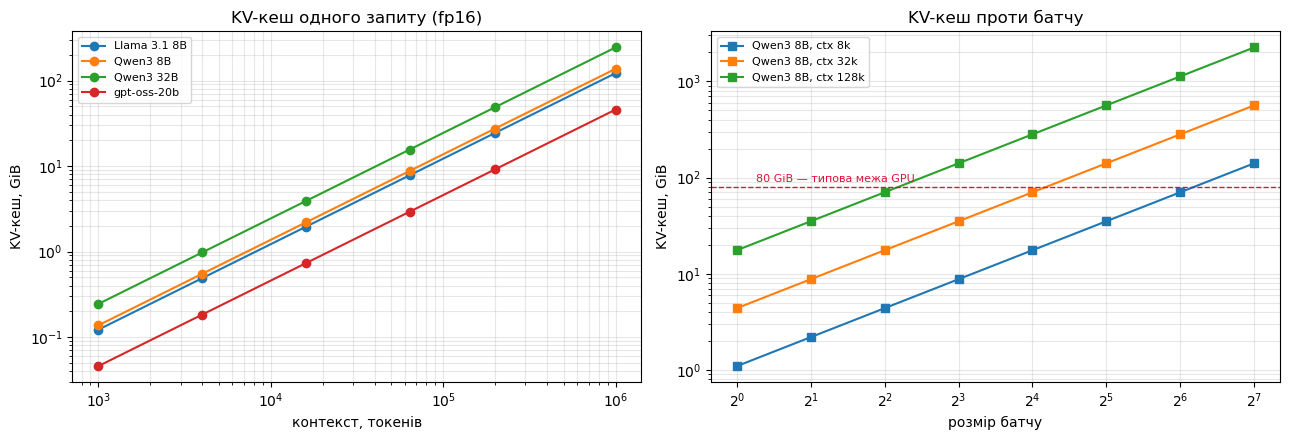

Кеш на 1M токенів у Qwen3 8B: 137.3 GiB
Тобто більше, ніж ваги моделі — «1M контексту» на власному залізі це пам'ять під кеш.


In [8]:
try:
    import matplotlib
    matplotlib.use("module://matplotlib_inline.backend_inline")
except Exception:
    pass
import matplotlib.pyplot as plt

fig, (ax_ctx, ax_batch) = plt.subplots(1, 2, figsize=(13, 4.5))

ctx_axis = [1_000, 4_000, 16_000, 64_000, 200_000, 1_000_000]
for label, cfg in CONFIGS.items():
    gib = [kv_bytes_per_token(cfg) * ctx / 1024 ** 3 for ctx in ctx_axis]
    ax_ctx.plot(ctx_axis, gib, marker="o", label=label)
ax_ctx.set_xscale("log")
ax_ctx.set_yscale("log")
ax_ctx.set_xlabel("контекст, токенів")
ax_ctx.set_ylabel("KV-кеш, GiB")
ax_ctx.set_title("KV-кеш одного запиту (fp16)")
ax_ctx.grid(True, which="both", alpha=0.3)
ax_ctx.legend(fontsize=8)

batch_axis = [1, 2, 4, 8, 16, 32, 64, 128]
for ctx_label, ctx in (("8k", 8_000), ("32k", 32_000), ("128k", 128_000)):
    gib = [per_token_qwen * ctx * b / 1024 ** 3 for b in batch_axis]
    ax_batch.plot(batch_axis, gib, marker="s", label=f"Qwen3 8B, ctx {ctx_label}")
ax_batch.axhline(80, color="crimson", linestyle="--", linewidth=1)
ax_batch.text(1.2, 90, "80 GiB — типова межа GPU", color="crimson", fontsize=8)
ax_batch.set_xscale("log", base=2)
ax_batch.set_yscale("log")
ax_batch.set_xlabel("розмір батчу")
ax_batch.set_ylabel("KV-кеш, GiB")
ax_batch.set_title("KV-кеш проти батчу")
ax_batch.grid(True, which="both", alpha=0.3)
ax_batch.legend(fontsize=8)

fig.tight_layout()
plt.show()
print("Кеш на 1M токенів у Qwen3 8B:", round(kv_bytes_per_token(cfg_qwen) * 1_000_000 / 1024 ** 3, 1), "GiB")
print("Тобто більше, ніж ваги моделі — «1M контексту» на власному залізі це пам'ять під кеш.")

Формула ламається на моделях із **sliding window attention**: кеш таких шарів
перестає рости після досягнення вікна. У `config.json` моделі gpt-oss-20b є поле
`layer_types`, яке прямо це описує.

In [9]:
cfg_oss = CONFIGS["gpt-oss-20b"]
layer_types = cfg_oss["layer_types"]
n_sliding = layer_types.count("sliding_attention")
n_full = layer_types.count("full_attention")
window = cfg_oss["sliding_window"]
per_layer_bytes = 2 * cfg_oss["num_key_value_heads"] * head_dim_of(cfg_oss) * 2

print(f"gpt-oss-20b: {cfg_oss['num_hidden_layers']} шарів -> sliding {n_sliding}, "
      f"full {n_full}; sliding_window={window}")
print(f"{per_layer_bytes:,} байтів/токен на шар")
print()
print(f"{'контекст':>10}{'гібрид, MiB':>14}{'усі шари як full, MiB':>24}{'економія':>10}")
for ctx in (8_000, 32_000, 128_000):
    full_bytes = per_layer_bytes * n_full * ctx
    sliding_bytes = per_layer_bytes * n_sliding * min(ctx, window)
    naive_bytes = per_layer_bytes * cfg_oss["num_hidden_layers"] * ctx
    hybrid = full_bytes + sliding_bytes
    print(f"{ctx:>10,}{hybrid / 1024 ** 2:>13.1f} {naive_bytes / 1024 ** 2:>22.1f}"
          f"{(1 - hybrid / naive_bytes) * 100:>9.1f}%")
print()
print("Половина шарів має вікно 128 токенів, тож їхній кеш не залежить від довжини контексту.")

gpt-oss-20b: 24 шарів -> sliding 12, full 12; sliding_window=128
2,048 байтів/токен на шар

  контекст   гібрид, MiB   усі шари як full, MiB  економія
     8,000        190.5                  375.0     49.2%
    32,000        753.0                 1500.0     49.8%
   128,000       3003.0                 6000.0     50.0%

Половина шарів має вікно 128 токенів, тож їхній кеш не залежить від довжини контексту.


Блокове зберігання дає ще один ефект: однакові префікси різних запитів можуть
посилатися на ті самі фізичні блоки. vLLM хешує кожен блок за схемою
`(parent_hash, block_tokens, salt)` через `sha256`, і кешує **лише повні блоки**
(`research/02/vllm-prefix-caching-design.md`). Відтворимо схему: два запити зі
спільним системним промптом.

In [10]:
import hashlib

BLOCK_SIZE = 16


def block_hashes(token_ids: list, block_size: int = BLOCK_SIZE, salt: str = "tenant-a") -> list:
    """Хеші повних блоків за схемою vLLM: parent_hash + токени блоку + salt (sha256)."""
    result = []
    parent = ""
    for offset in range(0, len(token_ids) - block_size + 1, block_size):
        chunk = tuple(token_ids[offset:offset + block_size])
        parent = hashlib.sha256(repr((parent, chunk, salt)).encode()).hexdigest()[:16]
        result.append(parent)
    return result


system_prompt = list(range(1000, 1000 + 12 * BLOCK_SIZE))    # 12 повних блоків + хвіст
request_a = system_prompt + [7, 8, 9]                        # неповний хвіст — не кешується
request_b = system_prompt + [11, 12]

blocks_a = block_hashes(request_a)
blocks_b = block_hashes(request_b)
print(f"системний промпт: {len(system_prompt)} токенів = {len(system_prompt) // BLOCK_SIZE} повних блоків")
print(f"запит A: {len(request_a)} токенів -> закешовано блоків {len(blocks_a)}")
print(f"запит B: {len(request_b)} токенів -> закешовано блоків {len(blocks_b)}")
print(f"спільних хешів блоків: {len(set(blocks_a) & set(blocks_b))}")
print()
print("перші три хеші запиту A:", blocks_a[:3])
print("перші три хеші запиту B:", blocks_b[:3])
print("хвіст із 3 токенів не кешується — він не утворює повного блоку.")
print()
shifted = block_hashes([0] + system_prompt + [7, 8, 9])
print(f"зсув на один токен на початку -> спільних блоків: {len(set(shifted) & set(blocks_a))}")
print("Один зайвий токен на початку промпту обнуляє весь кеш — та сама причина,")
print("що й у хмарному префіксному кеші (розділ 9).")

системний промпт: 192 токенів = 12 повних блоків
запит A: 195 токенів -> закешовано блоків 12
запит B: 194 токенів -> закешовано блоків 12
спільних хешів блоків: 12

перші три хеші запиту A: ['5e90647bb46111eb', '903a75bbd06c2f9b', '18232c6f35f3fd2d']
перші три хеші запиту B: ['5e90647bb46111eb', '903a75bbd06c2f9b', '18232c6f35f3fd2d']
хвіст із 3 токенів не кешується — він не утворює повного блоку.

зсув на один токен на початку -> спільних блоків: 0
Один зайвий токен на початку промпту обнуляє весь кеш — та сама причина,
що й у хмарному префіксному кеші (розділ 9).


Тепер звірка з чужими опублікованими числами — найшвидший спосіб знайти помилку в
одиницях або в множнику. HF-блог про Llama 3.1 публікує таблицю вимог KV-кешу.

In [11]:
# Опубліковані значення з research/02/hf-blog-llama31-memory.txt («In FP16, the KV cache
# memory requirements are»). Одиниці в блозі підписані як GB.
PUBLISHED = {
    "8B": {1_000: 0.125, 16_000: 1.95, 128_000: 15.62},
    "70B": {1_000: 0.313, 16_000: 4.88, 128_000: 39.06},
    "405B": {1_000: 0.984, 16_000: 15.38, 128_000: 123.05},
}
# (num_hidden_layers, num_key_value_heads, head_dim) для Llama 3.1 — з карток моделей.
LLAMA_ARCH = {"8B": (32, 8, 128), "70B": (80, 8, 128), "405B": (126, 8, 128)}

print("Звірка: опублікована таблиця HF проти формули")
print(f"{'модель':>8}{'контекст':>10}{'опубліковано':>14}{'формула, GiB':>14}{'різниця':>10}")
for size, (n_layers, n_kv, dim_head) in LLAMA_ARCH.items():
    per_token = 2 * n_layers * n_kv * dim_head * 2
    for ctx, published_value in PUBLISHED[size].items():
        calc = per_token * ctx / 1024 ** 3
        print(f"{size:>8}{ctx:>10,}{published_value:>13.3f} {calc:>13.3f}"
              f"{(calc / published_value - 1) * 100:>+9.1f}%")
print()
print("Рядок 405B розходиться рівно вдвічі — це помилка в опублікованій таблиці (FP32 замість")
print("FP16). Два коментарі в тому самому джерелі помітили це незалежно:")
print("  «these three values look like from FP32, could you double-check it?»")
print("  «405b at 128k should be in the ~66gb ballpark» — розрахунок дає 61.5 GiB.")

Звірка: опублікована таблиця HF проти формули
  модель  контекст  опубліковано  формула, GiB   різниця
      8B     1,000        0.125         0.122     -2.3%
      8B    16,000        1.950         1.953     +0.2%
      8B   128,000       15.620        15.625     +0.0%
     70B     1,000        0.313         0.305     -2.5%
     70B    16,000        4.880         4.883     +0.1%
     70B   128,000       39.060        39.062     +0.0%
    405B     1,000        0.984         0.481    -51.2%
    405B    16,000       15.380         7.690    -50.0%
    405B   128,000      123.050        61.523    -50.0%

Рядок 405B розходиться рівно вдвічі — це помилка в опублікованій таблиці (FP32 замість
FP16). Два коментарі в тому самому джерелі помітили це незалежно:
  «these three values look like from FP32, could you double-check it?»
  «405b at 128k should be in the ~66gb ballpark» — розрахунок дає 61.5 GiB.


## 2.2 Префіл і декодування: TTFT та TPOT

Формула затримки з `research/02/databricks-llm-inference-performance.txt`:

```text
latency = (TTFT) + (TPOT) * (the number of tokens to be generated)
```

Модель далі — синтетична: коефіцієнти підібрані під типові значення TPOT із
джерел. Вона потрібна, щоб відповісти на питання «де мій бюджет затримки», а не
щоб передбачити чужий сервіс.

In [12]:
def latency_seconds(ttft_ms: float, tpot_ms: float, output_tokens: int) -> float:
    """Модель затримки з джерела: latency = TTFT + TPOT * n_output."""
    return ttft_ms / 1000 + tpot_ms / 1000 * output_tokens


TTFT_MS, TPOT_MS = 300.0, 12.0
print(f"TTFT {TTFT_MS:.0f} мс, TPOT {TPOT_MS:.0f} мс — скільки важить TTFT")
print(f"{'вихід':>8}{'затримка':>11}{'декод':>9}{'частка TTFT':>13}")
for n_out in (50, 100, 500, 2_000, 8_000):
    total_s = latency_seconds(TTFT_MS, TPOT_MS, n_out)
    decode_s = TPOT_MS * n_out / 1000
    print(f"{n_out:>8}{total_s:>10.2f}s{decode_s:>8.2f}s{TTFT_MS / 1000 / total_s * 100:>12.1f}%")
print()
print("TPOT -> швидкість на одного користувача (1 токен ≈ 1.5 слова)")
print(f"{'TPOT, мс':>9}{'tok/s':>9}{'токенів/хв':>13}{'слів/хв':>10}")
for tpot in (5, 10, 20, 50, 100, 200):
    tps = 1000 / tpot
    print(f"{tpot:>9}{tps:>9.1f}{tps * 60:>13.0f}{tps * 60 / 1.5:>10.0f}")
print()
print("Межа читання людини — приблизно 450 слів/хв, тобто TPOT 100 мс.")

TTFT 300 мс, TPOT 12 мс — скільки важить TTFT
   вихід   затримка    декод  частка TTFT
      50      0.90s    0.60s        33.3%
     100      1.50s    1.20s        20.0%
     500      6.30s    6.00s         4.8%
    2000     24.30s   24.00s         1.2%
    8000     96.30s   96.00s         0.3%

TPOT -> швидкість на одного користувача (1 токен ≈ 1.5 слова)
 TPOT, мс    tok/s   токенів/хв   слів/хв
        5    200.0        12000      8000
       10    100.0         6000      4000
       20     50.0         3000      2000
       50     20.0         1200       800
      100     10.0          600       400
      200      5.0          300       200

Межа читання людини — приблизно 450 слів/хв, тобто TPOT 100 мс.


Декодування впирається в пропускну здатність пам'яті. Databricks вимірює це метрикою
MBU: `(achieved memory bandwidth) / (peak memory bandwidth)`, де achieved —
`(total model parameter size + KV cache size) / TPOT`. Порахуємо для моделі 7B у fp16.

In [13]:
PARAMS_7B = 7e9
FP16_BYTES = 2
PEAK_BW_BYTES = 2e12                      # 2 ТБ/с
model_bytes = PARAMS_7B * FP16_BYTES

print("MBU: приклад із research/02/nvidia-mastering-llm-inference-optimization.txt")
print(f"ваги моделі: {model_bytes / 1e9:.0f} GB; пікова смуга: {PEAK_BW_BYTES / 1e12:.0f} TB/s")
print()
print(f"{'TPOT, мс':>9}{'переміщено':>14}{'MBU':>8}   що це означає")
for tpot in (7, 10, 14, 20, 28):
    achieved = model_bytes / (tpot / 1000)
    mbu = achieved / PEAK_BW_BYTES
    if mbu >= 0.99:
        verdict = "смуга вичерпана"
    elif mbu >= 0.5:
        verdict = "є невеликий запас"
    else:
        verdict = "залізо простоює — шукайте вузьке місце"
    print(f"{tpot:>9}{achieved / 1e12:>12.2f} TB/s{mbu * 100:>7.0f}%   {verdict}")
print()
print("Тобто квантизація ваг прискорює генерацію: менше байтів на той самий токен.")

MBU: приклад із research/02/nvidia-mastering-llm-inference-optimization.txt
ваги моделі: 14 GB; пікова смуга: 2 TB/s

 TPOT, мс    переміщено     MBU   що це означає
        7        2.00 TB/s    100%   смуга вичерпана
       10        1.40 TB/s     70%   є невеликий запас
       14        1.00 TB/s     50%   є невеликий запас
       20        0.70 TB/s     35%   залізо простоює — шукайте вузьке місце
       28        0.50 TB/s     25%   залізо простоює — шукайте вузьке місце

Тобто квантизація ваг прискорює генерацію: менше байтів на той самий токен.


Тепер батчинг. Дані нижче — реальні вимірювання з Table 2 документації Databricks
(MPT-7B, запити 512 вхідних / 64 вихідних токенів), а не модель. Зверніть увагу на
останній стовпець: приріст від подвоєння батчу швидко падає.

In [14]:
BATCHES = [1, 4, 8, 16, 32, 64, 128]
THROUGHPUT = {
    "1 x A10": [0.4, 1.4, 2.3, 3.5, None, None, None],
    "1 x A100": [0.9, 3.2, 5.3, 8.0, 10.5, 12.5, None],
    "4 x A100": [1.7, 6.2, 11.5, 18.0, 25.0, 33.0, 36.5],
}
print("req/sec за Databricks Table 2 (None = OOM)")
print(f"{'hardware':10}" + "".join(f"{b:>9}" for b in BATCHES))
for hardware, values in THROUGHPUT.items():
    print(f"{hardware:10}" + "".join("        -" if v is None else f"{v:>9.1f}" for v in values))
print()
print("кратність до batch=1")
for hardware, values in THROUGHPUT.items():
    base = values[0]
    print(f"{hardware:10}" + "".join("        -" if v is None else f"{v / base:>8.1f}x" for v in values))
print()
print("приріст від ПОДВОЄННЯ батчу")
for hardware, values in THROUGHPUT.items():
    gains = []
    for idx in range(1, len(values)):
        prev, cur = values[idx - 1], values[idx]
        gains.append("     -  " if cur is None else f"{cur / prev:7.2f}x")
    print(f"{hardware:10}" + "".join(f"{g:>9}" for g in gains))
print()
print("Подвоєння 1->4 дає 3.5-3.7x, а 64->128 лише 1.1x: після переходу в compute-bound")
print("режим батч додає затримку і не додає пропускної здатності.")

req/sec за Databricks Table 2 (None = OOM)
hardware          1        4        8       16       32       64      128
1 x A10         0.4      1.4      2.3      3.5        -        -        -
1 x A100        0.9      3.2      5.3      8.0     10.5     12.5        -
4 x A100        1.7      6.2     11.5     18.0     25.0     33.0     36.5

кратність до batch=1
1 x A10        1.0x     3.5x     5.7x     8.8x        -        -        -
1 x A100       1.0x     3.6x     5.9x     8.9x    11.7x    13.9x        -
4 x A100       1.0x     3.6x     6.8x    10.6x    14.7x    19.4x    21.5x

приріст від ПОДВОЄННЯ батчу
1 x A10       3.50x    1.64x    1.52x      -        -        -  
1 x A100      3.56x    1.66x    1.51x    1.31x    1.19x      -  
4 x A100      3.65x    1.85x    1.57x    1.39x    1.32x    1.11x

Подвоєння 1->4 дає 3.5-3.7x, а 64->128 лише 1.1x: після переходу в compute-bound
режим батч додає затримку і не додає пропускної здатності.


Той самий компроміс із погляду користувача: зростання батчу підвищує сумарну
пропускну здатність, але погіршує TPOT кожного окремого запиту. Профіль нижче —
модель, побудована на типових значеннях TPOT; вона показує форму кривої.

In [15]:
BATCH_PROFILE = [(1, 12.0), (4, 13.0), (16, 18.0), (64, 45.0), (128, 90.0)]
print(f"{'batch':>7}{'TPOT, мс':>11}{'tok/s на користувача':>23}{'сумарно tok/s':>16}")
for batch_size, tpot_ms in BATCH_PROFILE:
    per_user = 1000 / tpot_ms
    print(f"{batch_size:>7}{tpot_ms:>11.1f}{per_user:>23.1f}{batch_size * per_user:>16.0f}")
print()
print("Сумарна пропускна здатність росте до певної межі й далі не росте, а TPOT падає весь час.")
print("Це той самий перехід у compute-bound режим, що й у попередній таблиці.")

  batch   TPOT, мс   tok/s на користувача   сумарно tok/s
      1       12.0                   83.3              83
      4       13.0                   76.9             308
     16       18.0                   55.6             889
     64       45.0                   22.2            1422
    128       90.0                   11.1            1422

Сумарна пропускна здатність росте до певної межі й далі не росте, а TPOT падає весь час.
Це той самий перехід у compute-bound режим, що й у попередній таблиці.


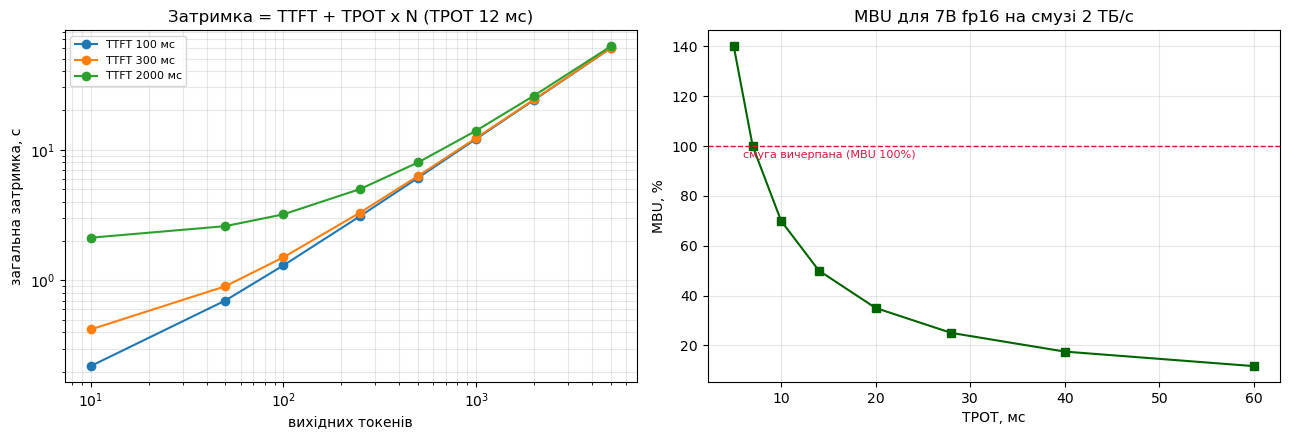

Лівий графік: на довгих відповідях TTFT майже не впливає на загальну затримку.
Правий: TPOT нижче ~7 мс на цьому залізі фізично недосяжний для 7B fp16.


In [16]:
fig, (ax_lat, ax_mbu) = plt.subplots(1, 2, figsize=(13, 4.5))

out_axis = [10, 50, 100, 250, 500, 1_000, 2_000, 5_000]
for ttft_label, ttft_model in (("TTFT 100 мс", 100.0), ("TTFT 300 мс", 300.0), ("TTFT 2000 мс", 2_000.0)):
    totals = [latency_seconds(ttft_model, TPOT_MS, n) for n in out_axis]
    ax_lat.plot(out_axis, totals, marker="o", label=ttft_label)
ax_lat.set_xscale("log")
ax_lat.set_yscale("log")
ax_lat.set_xlabel("вихідних токенів")
ax_lat.set_ylabel("загальна затримка, с")
ax_lat.set_title(f"Затримка = TTFT + TPOT x N (TPOT {TPOT_MS:.0f} мс)")
ax_lat.grid(True, which="both", alpha=0.3)
ax_lat.legend(fontsize=8)

tpot_axis = [5, 7, 10, 14, 20, 28, 40, 60]
mbu_values = [model_bytes / (t / 1000) / PEAK_BW_BYTES * 100 for t in tpot_axis]
ax_mbu.plot(tpot_axis, mbu_values, marker="s", color="darkgreen")
ax_mbu.axhline(100, color="crimson", linestyle="--", linewidth=1)
ax_mbu.text(6, 95, "смуга вичерпана (MBU 100%)", color="crimson", fontsize=8)
ax_mbu.set_xlabel("TPOT, мс")
ax_mbu.set_ylabel("MBU, %")
ax_mbu.set_title("MBU для 7B fp16 на смузі 2 ТБ/с")
ax_mbu.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()
print("Лівий графік: на довгих відповідях TTFT майже не впливає на загальну затримку.")
print("Правий: TPOT нижче ~7 мс на цьому залізі фізично недосяжний для 7B fp16.")

## 2.4 Довгий контекст: накопичення і ціна

Кожен хід багатоходового діалогу відправляє **всю історію заново**. Тому ціна
діалогу росте як сума арифметичної прогресії, тобто квадратично за кількістю ходів.
Порахуємо, скільки ходів уміщує вікно і скільки це коштує.

In [17]:
SYS_TOKENS = 3_000
TURN_USER_TOKENS = 200
TURN_OUT_TOKENS = 600
PRICE_IN, PRICE_OUT = 2.0, 10.0       # Claude Sonnet 5, $/MTok


def input_tokens_at_turn(turn: int) -> int:
    """Вхідні токени запиту на ході turn (1-based) без compaction."""
    return SYS_TOKENS + (turn - 1) * (TURN_USER_TOKENS + TURN_OUT_TOKENS) + TURN_USER_TOKENS


def dialogue_cost(n_turns: int) -> float:
    return sum(input_tokens_at_turn(t) / 1e6 * PRICE_IN
               + TURN_OUT_TOKENS / 1e6 * PRICE_OUT for t in range(1, n_turns + 1))


print("Скільки ходів уміщує вікно")
for context_window in (200_000, 1_000_000):
    limit_turn = next(t for t in range(1, 20_000)
                      if input_tokens_at_turn(t) + TURN_OUT_TOKENS > context_window)
    total_in = sum(input_tokens_at_turn(t) for t in range(1, limit_turn))
    print(f"  вікно {context_window:>9,}: межа на ході {limit_turn:>5} | сумарний вхід"
          f" {total_in:>13,} токенів | ${total_in / 1e6 * PRICE_IN:>9.2f} тільки на вхід")
print()
print(f"{'ходів':>7}{'вхід на останньому ході':>26}{'сумарний вхід':>16}{'ціна діалогу':>15}")
for n_turns in (5, 10, 20, 40, 80):
    total_in = sum(input_tokens_at_turn(t) for t in range(1, n_turns + 1))
    print(f"{n_turns:>7}{input_tokens_at_turn(n_turns):>26,}{total_in:>16,}"
          f"{dialogue_cost(n_turns):>14.4f}$")
print()
print("Подвоєння діалогу з 40 до 80 ходів збільшує ціну в 3.5 раза, а не вдвічі.")

Скільки ходів уміщує вікно
  вікно   200,000: межа на ході   247 | сумарний вхід    24,895,200 токенів | $    49.79 тільки на вхід
  вікно 1,000,000: межа на ході  1247 | сумарний вхід   624,495,200 токенів | $  1248.99 тільки на вхід

  ходів   вхід на останньому ході   сумарний вхід   ціна діалогу
      5                     6,400          24,000        0.0780$
     10                    10,400          68,000        0.1960$
     20                    18,400         216,000        0.5520$
     40                    34,400         752,000        1.7440$
     80                    66,400       2,784,000        6.0480$

Подвоєння діалогу з 40 до 80 ходів збільшує ціну в 3.5 раза, а не вдвічі.


Тепер compaction: кожні 10 ходів історія стискається до резюме на 1 500 токенів. Це
не просто знижує ціну — це **зупиняє зростання**, бо контекст перестає накопичуватися.

In [18]:
SUMMARY_TOKENS = 1_500
COMPACT_EVERY = 10


def dialogue_cost_with_compaction(n_turns: int) -> tuple[float, int]:
    """Ціна з періодичним стисненням історії. Повертає (ціна, вхід на останньому ході)."""
    ctx_tokens = SYS_TOKENS + SUMMARY_TOKENS
    spent = 0.0
    for turn_idx in range(1, n_turns + 1):
        ctx_tokens += TURN_USER_TOKENS
        spent += ctx_tokens / 1e6 * PRICE_IN + TURN_OUT_TOKENS / 1e6 * PRICE_OUT
        ctx_tokens += TURN_OUT_TOKENS
        if turn_idx % COMPACT_EVERY == 0:
            ctx_tokens = SYS_TOKENS + SUMMARY_TOKENS
    return spent, ctx_tokens


print(f"{'ходів':>7}{'вхід на останньому ході':>26}{'ціна':>12}{'проти без compaction':>22}")
for n_turns in (20, 40, 80):
    compacted, last_ctx = dialogue_cost_with_compaction(n_turns)
    base = dialogue_cost(n_turns)
    print(f"{n_turns:>7}{last_ctx:>26,}{compacted:>11.4f}${(1 - compacted / base) * 100:>20.1f}%")
print()
print("Без compaction вхід на останньому ході росте лінійно; з compaction він сталий.")

  ходів   вхід на останньому ході        ціна  проти без compaction
     20                     4,500     0.4520$                18.1%
     40                     4,500     0.9040$                48.2%
     80                     4,500     1.8080$                70.1%

Без compaction вхід на останньому ході росте лінійно; з compaction він сталий.


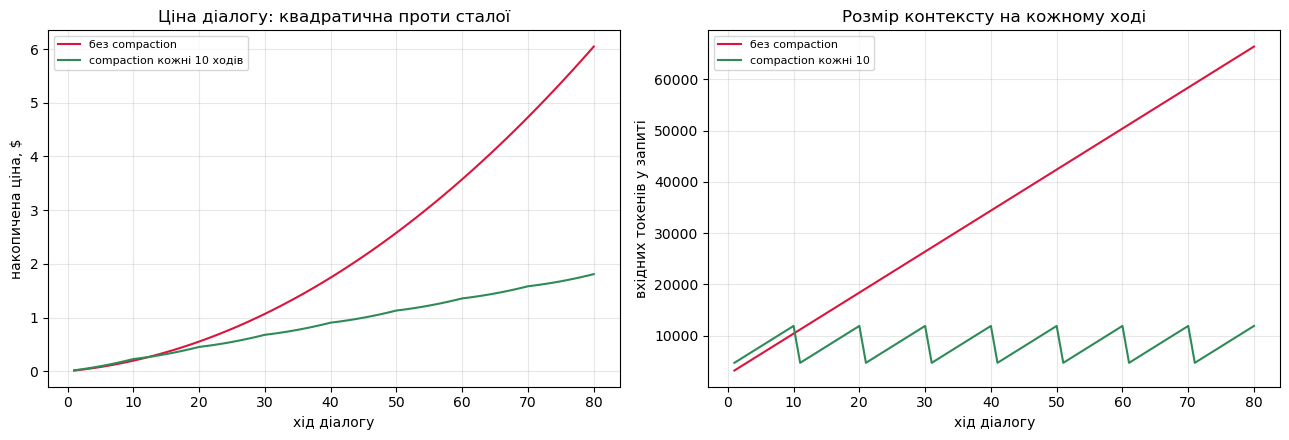

Ціна без compaction росте квадратично; compaction робить її лінійною.


In [19]:
turn_axis = list(range(1, 81))
cost_plain = []
cost_compact = []
running_plain = 0.0
running_compact = 0.0
ctx_compact = SYS_TOKENS + SUMMARY_TOKENS
for turn_no in turn_axis:
    running_plain += input_tokens_at_turn(turn_no) / 1e6 * PRICE_IN + TURN_OUT_TOKENS / 1e6 * PRICE_OUT
    cost_plain.append(running_plain)
    ctx_compact += TURN_USER_TOKENS
    running_compact += ctx_compact / 1e6 * PRICE_IN + TURN_OUT_TOKENS / 1e6 * PRICE_OUT
    ctx_compact += TURN_OUT_TOKENS
    if turn_no % COMPACT_EVERY == 0:
        ctx_compact = SYS_TOKENS + SUMMARY_TOKENS
    cost_compact.append(running_compact)

fig, (ax_cost, ax_ctx) = plt.subplots(1, 2, figsize=(13, 4.5))
ax_cost.plot(turn_axis, cost_plain, label="без compaction", color="crimson")
ax_cost.plot(turn_axis, cost_compact, label=f"compaction кожні {COMPACT_EVERY} ходів", color="seagreen")
ax_cost.set_xlabel("хід діалогу")
ax_cost.set_ylabel("накопичена ціна, $")
ax_cost.set_title("Ціна діалогу: квадратична проти сталої")
ax_cost.grid(True, alpha=0.3)
ax_cost.legend(fontsize=8)

ax_ctx.plot(turn_axis, [input_tokens_at_turn(t) for t in turn_axis], label="без compaction", color="crimson")
ctx_series = []
ctx_running = SYS_TOKENS + SUMMARY_TOKENS
for turn_no in turn_axis:
    ctx_running += TURN_USER_TOKENS
    ctx_series.append(ctx_running)
    ctx_running += TURN_OUT_TOKENS
    if turn_no % COMPACT_EVERY == 0:
        ctx_running = SYS_TOKENS + SUMMARY_TOKENS
ax_ctx.plot(turn_axis, ctx_series, label=f"compaction кожні {COMPACT_EVERY}", color="seagreen")
ax_ctx.set_xlabel("хід діалогу")
ax_ctx.set_ylabel("вхідних токенів у запиті")
ax_ctx.set_title("Розмір контексту на кожному ході")
ax_ctx.grid(True, alpha=0.3)
ax_ctx.legend(fontsize=8)
fig.tight_layout()
plt.show()
print("Ціна без compaction росте квадратично; compaction робить її лінійною.")

## 2.5 Арифметика вартості

Ціна виходу вища за ціну входу в усіх великих провайдерів. Перевіримо це на
реальних прайс-листах і подивимося, який розкид.

In [20]:
# Ціни за 1M токенів, 09.2026. DeepSeek — PEAK-ставки (off-peak удвічі дешевші).
CATALOG = {
    "Claude Sonnet 5": dict(inp=2.00, out=10.0, read=0.20, cw=2.50),
    "Claude Opus 5": dict(inp=5.00, out=25.0, read=0.50, cw=6.25),
    "Claude Haiku 4.5": dict(inp=1.00, out=5.00, read=0.10, cw=1.25),
    "gpt-6-astra": dict(inp=10.0, out=50.0, read=1.00, cw=12.50),
    "gpt-5.6-terra": dict(inp=2.00, out=12.0, read=0.20, cw=2.50),
    "gpt-5-nano": dict(inp=0.05, out=0.40, read=0.005, cw=0.0625),
    "deepseek-v4-pro": dict(inp=1.32, out=3.96, read=0.044, cw=None),
    "deepseek-flash": dict(inp=0.30, out=1.20, read=0.006, cw=None),
}
print(f"{'модель':20}{'вхід':>9}{'вихід':>9}{'out/in':>9}{'кеш-читання':>14}")
for model_name, price in CATALOG.items():
    print(f"{model_name:20}{price['inp']:>8.2f}$ {price['out']:>8.2f}$ "
          f"{price['out'] / price['inp']:>8.1f}x{price['read'] / price['inp'] * 100:>13.1f}%")
ratios = [price["out"] / price["inp"] for price in CATALOG.values()]
print()
print(f"розкид співвідношення out/in: {min(ratios):.1f}x ... {max(ratios):.1f}x")

модель                   вхід    вихід   out/in   кеш-читання
Claude Sonnet 5         2.00$    10.00$      5.0x         10.0%
Claude Opus 5           5.00$    25.00$      5.0x         10.0%
Claude Haiku 4.5        1.00$     5.00$      5.0x         10.0%
gpt-6-astra            10.00$    50.00$      5.0x         10.0%
gpt-5.6-terra           2.00$    12.00$      6.0x         10.0%
gpt-5-nano              0.05$     0.40$      8.0x         10.0%
deepseek-v4-pro         1.32$     3.96$      3.0x          3.3%
deepseek-flash          0.30$     1.20$      4.0x          2.0%

розкид співвідношення out/in: 3.0x ... 8.0x


Який із двох режимів дорожчий — один довгий запит чи багато коротких, при однаковому
обсязі входу? Відповідь залежить від виходу, а не від входу.

In [21]:
SONNET_IN, SONNET_OUT, SONNET_READ = 2.00, 10.00, 0.20


def request_cost(calls: int, tokens_in: int, tokens_out: int) -> tuple[float, float]:
    """Повертає (ціна, частка виходу у відсотках)."""
    spent = calls * (tokens_in / 1e6 * SONNET_IN + tokens_out / 1e6 * SONNET_OUT)
    share = calls * tokens_out / 1e6 * SONNET_OUT / spent * 100
    return spent, share


SHAPES = [
    ("1 запит: 200k in / 500 out", 1, 200_000, 500),
    ("20 запитів: 10k in / 500 out", 20, 10_000, 500),
    ("100 запитів: 2k in / 500 out", 100, 2_000, 500),
    ("1 запит: 2k in / 100k out", 1, 2_000, 100_000),
]
print(f"{'варіант':32}{'вхід':>11}{'вихід':>10}{'ціна':>11}{'частка виходу':>15}")
for shape_label, calls, tokens_in, tokens_out in SHAPES:
    spent, share = request_cost(calls, tokens_in, tokens_out)
    print(f"{shape_label:32}{calls * tokens_in:>11,}{calls * tokens_out:>10,}"
          f"{spent:>10.4f}${share:>14.1f}%")
print()
print("Перші три рядки — однакові 200 000 вхідних токенів, розбиті по-різному: різниця 2.2x.")

варіант                                вхід     вихід       ціна  частка виходу
1 запит: 200k in / 500 out          200,000       500    0.4050$           1.2%
20 запитів: 10k in / 500 out        200,000    10,000    0.5000$          20.0%
100 запитів: 2k in / 500 out        200,000    50,000    0.9000$          55.6%
1 запит: 2k in / 100k out             2,000   100,000    1.0040$          99.6%

Перші три рядки — однакові 200 000 вхідних токенів, розбиті по-різному: різниця 2.2x.


Тепер кеш. Його економіка описується двома числами: множником запису й множником
читання. Знайдемо поріг, за якого кеш окупається.

In [22]:
PREFIX_TOKENS = 100_000
plain_prefix = PREFIX_TOKENS / 1e6 * SONNET_IN
read_prefix = PREFIX_TOKENS / 1e6 * SONNET_READ
print(f"префікс {PREFIX_TOKENS:,} токенів: без кешу ${plain_prefix:.4f}, "
      f"читання з кешу ${read_prefix:.4f}")
print()
for write_mult, write_label in ((1.25, "запис 5 хв"), (2.0, "запис 1 год")):
    write_cost = plain_prefix * write_mult
    breakeven = (write_cost - plain_prefix) / (plain_prefix - read_prefix)
    print(f"{write_label}: запис ${write_cost:.4f}; беззбитковість після {breakeven:.2f} читань")
print()
print(f"{'запитів':>8}{'5-хв кеш':>12}{'проти без кешу':>16}{'1-год кеш':>12}{'проти без кешу':>16}")
for n_calls in (2, 3, 5, 10, 50):
    no_cache_cost = n_calls * plain_prefix
    cells = []
    for write_mult in (1.25, 2.0):
        cells.append(plain_prefix * write_mult + (n_calls - 1) * read_prefix)
    print(f"{n_calls:>8}{cells[0]:>11.4f}${(1 - cells[0] / no_cache_cost) * 100:>15.1f}%"
          f"{cells[1]:>11.4f}${(1 - cells[1] / no_cache_cost) * 100:>15.1f}%")
print()
print("Годинний кеш на двох запитах збитковий (-5%), 5-хвилинний — уже ні: TTL вирішує.")

префікс 100,000 токенів: без кешу $0.2000, читання з кешу $0.0200

запис 5 хв: запис $0.2500; беззбитковість після 0.28 читань
запис 1 год: запис $0.4000; беззбитковість після 1.11 читань

 запитів    5-хв кеш  проти без кешу   1-год кеш  проти без кешу
       2     0.2700$           32.5%     0.4200$           -5.0%
       3     0.2900$           51.7%     0.4400$           26.7%
       5     0.3300$           67.0%     0.4800$           52.0%
      10     0.4300$           78.5%     0.5800$           71.0%
      50     1.2300$           87.7%     1.3800$           86.2%

Годинний кеш на двох запитах збитковий (-5%), 5-хвилинний — уже ні: TTL вирішує.


Кеш — не єдина знижка. Множники складаються, тому варто порахувати комбінації: Batch
API (−50%), кеш і US-only (+1.1x) діють на один рахунок одночасно.

In [23]:
TASKS = 1_000
DOC_TOKENS = 20_000
OUT_TOKENS_PER_TASK = 300
GEO_MULT = 1.1                            # inference_geo = "us"

token_cost = (DOC_TOKENS / 1e6 * SONNET_IN + OUT_TOKENS_PER_TASK / 1e6 * SONNET_OUT) * TASKS
batched = token_cost * 0.5
cached_first = DOC_TOKENS / 1e6 * SONNET_IN * 1.25 + (TASKS - 1) * DOC_TOKENS / 1e6 * SONNET_READ
cached_then_batched = (cached_first + TASKS * OUT_TOKENS_PER_TASK / 1e6 * SONNET_OUT) * 0.5

print(f"{'сценарій':44}{'ціна':>12}{'до базової':>13}")
print(f"{'базова (1000 запитів синхронно)':44}{token_cost:>11.2f}${token_cost / token_cost:>12.2f}x")
print(f"{'кеш 5 хв (1 запис + 999 читань)':44}{cached_first + TASKS * OUT_TOKENS_PER_TASK / 1e6 * SONNET_OUT:>11.2f}$"
      f"{(cached_first + TASKS * OUT_TOKENS_PER_TASK / 1e6 * SONNET_OUT) / token_cost:>12.2f}x")
print(f"{'batch (-50%)':44}{batched:>11.2f}${batched / token_cost:>12.2f}x")
print(f"{'batch + кеш':44}{cached_then_batched:>11.2f}${cached_then_batched / token_cost:>12.2f}x")
print(f"{'batch + кеш + US-only (1.1x)':44}{cached_then_batched * GEO_MULT:>11.2f}$"
      f"{cached_then_batched * GEO_MULT / token_cost:>12.2f}x")
print()
cache_only = cached_first + TASKS * OUT_TOKENS_PER_TASK / 1e6 * SONNET_OUT
print(f"Знижки множаться, а не додаються: кеш дає {cache_only / token_cost:.2f}x, batch 0.50x,")
print(f"разом {cached_then_batched / token_cost:.2f}x, а надбавка за географію множиться поверх.")

сценарій                                            ціна   до базової
базова (1000 запитів синхронно)                   43.00$        1.00x
кеш 5 хв (1 запис + 999 читань)                    7.05$        0.16x
batch (-50%)                                      21.50$        0.50x
batch + кеш                                        3.52$        0.08x
batch + кеш + US-only (1.1x)                       3.88$        0.09x

Знижки множаться, а не додаються: кеш дає 0.16x, batch 0.50x,
разом 0.08x, а надбавка за географію множиться поверх.


Ліміти швидкості рахують не всі вхідні токени. Кеш-влучання не входить у ITPM, і саме
тому кеш розширює не лише бюджет, а й стелю швидкості.

In [24]:
ITPM = 2_000_000
print("Ефективний вхід за різної частки кеш-влучань (модель ITPM 2 000 000):")
print(f"{'влучань':>9}{'некешований вхід':>18}{'ефективний вхід':>18}{'розширення':>12}")
for hit_rate in (0.0, 0.5, 0.8, 0.95, 0.99):
    uncached = ITPM
    effective = ITPM / (1 - hit_rate)
    print(f"{hit_rate * 100:>8.0f}%{uncached:>18,}{effective:>18,.0f}{effective / ITPM:>11.2f}x")
print()
print("Документація: при 80% влучань ліміт 2M ITPM дає 10M вхідних токенів на хвилину.")

Ефективний вхід за різної частки кеш-влучань (модель ITPM 2 000 000):
  влучань  некешований вхід   ефективний вхід  розширення
       0%         2,000,000         2,000,000       1.00x
      50%         2,000,000         4,000,000       2.00x
      80%         2,000,000        10,000,000       5.00x
      95%         2,000,000        40,000,000      20.00x
      99%         2,000,000       200,000,000     100.00x

Документація: при 80% влучань ліміт 2M ITPM дає 10M вхідних токенів на хвилину.


## Опційно: виміряти TTFT і TPOT на реальному запиті

Клітинка нижче потребує `ANTHROPIC_API_KEY`. Вона міряє три речі: TTFT (час до
першої події `content_block_delta`), загальну затримку і TPOT за формулою vLLM
`(end-to-end - TTFT) / (output_tokens - 1)`.

Без ключа клітинка просто пояснить, що пропущено, — решта ноутбука працює без мережі.

In [25]:
import json as _json
import os
import time
import urllib.request

try:
    from dotenv import load_dotenv
    load_dotenv(ROOT / ".env")
except ImportError:
    pass

if not os.environ.get("ANTHROPIC_API_KEY"):
    print("ANTHROPIC_API_KEY не задано — клітинку пропущено.")
    print("Решта ноутбука працює без ключа й без мережі.")
else:
    payload = _json.dumps({
        "model": "claude-haiku-4-5",
        "max_tokens": 300,
        "stream": True,
        "messages": [{"role": "user", "content": "Порахуй від 1 до 40 через кому."}],
    }).encode("utf-8")
    request = urllib.request.Request(
        "https://api.anthropic.com/v1/messages",
        data=payload,
        headers={
            "x-api-key": os.environ["ANTHROPIC_API_KEY"],
            "anthropic-version": "2023-06-01",
            "content-type": "application/json",
        },
    )
    try:
        started = time.perf_counter()
        ttft = None
        output_tokens = 0
        with urllib.request.urlopen(request, timeout=120) as response:
            for raw_line in response:
                line = raw_line.decode("utf-8").strip()
                if not line.startswith("data:"):
                    continue
                event = _json.loads(line[5:])
                if event.get("type") == "content_block_delta" and ttft is None:
                    ttft = time.perf_counter() - started
                usage = event.get("usage") or {}
                if usage.get("output_tokens"):
                    output_tokens = usage["output_tokens"]
        total = time.perf_counter() - started
        print(f"TTFT               : {ttft * 1000:.0f} мс")
        print(f"загальна затримка  : {total * 1000:.0f} мс")
        print(f"вихідних токенів   : {output_tokens}")
        if output_tokens > 1 and ttft is not None:
            tpot_measured = (total - ttft) / (output_tokens - 1)
            print(f"TPOT (формула vLLM): {tpot_measured * 1000:.1f} мс"
                  f" = {1 / tpot_measured:.1f} tok/s")
        print()
        print("Порівняйте з тим, що передбачає формула latency = TTFT + TPOT x N.")
    except Exception as exc:
        print(f"Помилка виклику API ({type(exc).__name__}): {exc}")

ANTHROPIC_API_KEY не задано — клітинку пропущено.
Решта ноутбука працює без ключа й без мережі.


## Підсумок

| Що порахували | Число | Джерело формули |
|---|---|---|
| KV-кеш Qwen3 8B на токен | 147 456 байтів (0.141 MiB) | NVIDIA + `config.json` |
| KV-кеш Qwen3 8B на 128k | 17.6 GiB на один запит | те саме |
| KV-кеш Qwen3 8B, batch 32, 32k | 140.6 GiB | те саме |
| Виграш GQA проти MHA | 4x (Qwen3 8B) … 8x (Qwen3 32B) | `config.json` |
| Виграш sliding window (gpt-oss-20b) | 50% кешу | `layer_types` у конфізі |
| Затримка | `TTFT + TPOT × N` | Databricks |
| TPOT | `(end-to-end − TTFT) / (N_out − 1)` | vLLM |
| MBU 7B fp16 при TPOT 14 мс | 50% | Databricks |
| Ходів у вікні 1M (sys 3k, 200/600) | 1247, тобто 624 млн вхідних токенів | розрахунок |
| Економія compaction | 70% на 80 ходах | розрахунок |
| Ціна виходу проти входу | 3x … 8x | прайс-листи |
| Беззбитковість кешу | 1 читання (5 хв), 2 читання (1 год) | `research/02/pricing.md` |

**Чекліст перед тим, як оптимізувати інференс:**

1. **Порахуйте `total_input_tokens`**, а не читайте `input_tokens`. Різниця може бути в тисячі разів.
2. **Знайдіть, що важить у рахунку** — вхід, кеш чи вихід. У більшості навантажень це вихід.
3. **Перевірте `num_key_value_heads`, а не `num_attention_heads`** у своєму розрахунку кешу. Помилка дає 4–8x.
4. **Порахуйте кеш на цільовому батчі й контексті** до того, як планувати розгортання.
5. **Подивіться, чи не вирішує задачу compaction** — вона зупиняє квадратичне зростання ціни.
6. **Перевірте TTL кешу під своє навантаження**: годинний запис на двох запитах збитковий.
7. **Міряйте TTFT і TPOT**, а не «швидкість» загалом: на довгих відповідях TTFT не має значення.

**Куди далі:**

- Розділ 3 — токенізація: чому `len(text)` не кількість токенів.
- Розділ 9 — префіксний кеш: практика й діагностика промахів.
- Розділ 10 — Batch API: друга знижка, яка множиться з кешем.
- Розділ 20 — квантизація: чому вона прискорює memory-bound декодування.
- Розділ 25 — сервінг: батчинг, PagedAttention і prefix caching у себе на залізі.

## Джерела

- [NVIDIA — Mastering LLM Techniques: Inference Optimization](https://developer.nvidia.com/blog/mastering-llm-techniques-inference-optimization/)
- [Databricks — LLM Inference Performance Engineering](https://www.databricks.com/blog/llm-inference-performance-engineering-best-practices)
- [vLLM — Metrics design](https://raw.githubusercontent.com/vllm-project/vllm/main/docs/design/metrics.md)
- [HF — How caching works](https://raw.githubusercontent.com/huggingface/transformers/main/docs/source/en/cache_explanation.md)
- [HF — Llama 3.1 (таблиця KV-кешу)](https://huggingface.co/blog/llama31)
- [Anthropic — Pricing](https://platform.claude.com/docs/en/about-claude/pricing)
- [Anthropic — Rate limits](https://platform.claude.com/docs/en/api/rate-limits)

Джерела збережено локально: `research/02/`, `research/02/configs/`, `research/econ/`.